In [ ]:
# link https://github.com/sanmayphy/MLSCHOOL_2026_TIFR/tree/main

In [1]:
# Standard libraries
import os
import math
import numpy as np
import time

# Imports for plotting
import matplotlib.pyplot as plt

# Progress bar
from tqdm.notebook import tqdm 

In [2]:
print(os.sys.path)

['/home/ehep23/ehep/root/install/lib', '/home/rajshah/anaconda3/envs/ml4hepv4-ml-tutorial/lib/python313.zip', '/home/rajshah/anaconda3/envs/ml4hepv4-ml-tutorial/lib/python3.13', '/home/rajshah/anaconda3/envs/ml4hepv4-ml-tutorial/lib/python3.13/lib-dynload', '', '/home/rajshah/anaconda3/envs/ml4hepv4-ml-tutorial/lib/python3.13/site-packages']


In [3]:
# Import pytorch
import torch
print(f"Using torch {torch.__version__}")

Using torch 2.11.0+cu128


In [4]:
# Set the right computational device
#print(torch.cuda.is_available())
#print(torch.backends.mps.is_available())
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(device)

cpu


In [5]:
# Set the seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [6]:
# Here we test a simple XOR classifier with two inputs and one hidden layer and tanh as activation function and a output layer.

# ============================================================
# XOR CLASSIFIER USING PYTORCH
# ============================================================
#
# Goal:
# Learn how to create a very small neural network in PyTorch.
#
# This network tries to solve the XOR problem:
#
# Input    Output
# ----------------
# 0 0  ->   0
# 0 1  ->   1
# 1 0  ->   1
# 1 1  ->   0
#
# XOR is important because:
# - It is NOT linearly separable
# - A single linear layer cannot solve it
# - We need:
#       1. Hidden layer
#       2. Nonlinear activation function
#
# ============================================================


In [7]:
#  Importing neural network module
#  torch.nn contains:
# - neural network layers
# - activation functions
# - loss functions
# - model utilities
# We rename it as "nn" for convenience.

import torch.nn as nn

In [8]:
# Create a custom NN classifier as derived class which is inherited from parent class "nn.Module", which provides functionality such as .train()
# .eval(), .parameters() and automatic differentiation support

class SimpleClassifier(nn.Module): 
    
    def __init__(self, num_inputs, num_hidden, num_outputs):
        super().__init__()   # Initialize parent class nn.Module
        self.linear1 = nn.Linear(num_inputs, num_hidden)
        self.act_fn = nn.Tanh()
        self.linear2 = nn.Linear(num_hidden, num_outputs)
    
    # FORWARD PASS
    
    def forward(self, x):
        # Perform the calculations of the model to determined prediction
        x = self.linear1(x)
        x = self.act_fn(x)
        x = self.linear2(x)
        return x

In [9]:
# Create model object
model = SimpleClassifier(num_inputs=2,num_hidden=4,num_outputs=1)
print(model)

SimpleClassifier(
  (linear1): Linear(in_features=2, out_features=4, bias=True)
  (act_fn): Tanh()
  (linear2): Linear(in_features=4, out_features=1, bias=True)
)


In [10]:
# Architecture:
#
# 2 Inputs
#    ↓
# Linear Layer
#    ↓
# 4 Hidden Neurons
#    ↓
# tanh Activation
#    ↓
# Linear Layer
#    ↓
# 1 Output

In [11]:
dir(model)

['T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_apply',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_compiled_call_impl',
 '_forward_hooks',
 '_forward_hooks_always_called',
 '_forward_hooks_with_kwargs',
 '_forward_pre_hooks',
 '_forward_pre_hooks_with_kwargs',
 '_get_backward_hooks',
 '_get_backward_pre_hooks',
 '_get_name',
 '_is_full_backward_hook',
 '_load_from_state_dict',
 '_load_state_dict_post_hooks',
 '_load_state_dict_pre_hooks',
 '_maybe_warn_non_full_backward_hook',
 '_modules',
 

In [12]:
# Print model parameters and its shape
for name, param in model.named_parameters():
    print(f"Parameter {name}, shape {param.shape}")

Parameter linear1.weight, shape torch.Size([4, 2])
Parameter linear1.bias, shape torch.Size([4])
Parameter linear2.weight, shape torch.Size([1, 4])
Parameter linear2.bias, shape torch.Size([1])


# Data Creation and Handling

In [13]:
from torch.utils.data import Dataset, DataLoader

In [14]:
data = torch.randint(0, 2, size=(10,2), dtype=torch.float32)
print(data)
and_ = torch.sum(data,dim=1) / 2
int(2 /2) 

tensor([[1., 1.],
        [0., 1.],
        [0., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 0.],
        [0., 1.],
        [1., 1.],
        [0., 1.]])


1

In [15]:
# See Documentaiton using "Dataset??" to see which methods need to be overridden.
class XORDataset(Dataset):
    def __init__(self, size, std=0.1):
        super().__init__()
        self.size = size
        self.std = std
        self.generate_continuous_xor()
        
    def generate_continuous_xor(self):
        data = torch.randint(0, 2, size=(self.size,2), dtype=torch.float32)
        #labels = (torch.sum(data,dim=1)==1).to(torch.long) # xor value
        #labels = (torch.prod(data,dim=1)).to(torch.long) # and
        labels = (torch.sum(data,dim=1)!=0).to(torch.long) # or value
        #labels = (torch.prod(data,dim=1)==0).to(torch.long) # nand
        
        # Add random noise to data
        data += self.std * torch.randn(data.shape)
        self.data = data
        self.label = labels
    
    def __getitem__(self, idx):
        # Return the idx-th data point of the dataset
        # If we have multiple things to return (data point and label), we can return them as tuple
        data_point = self.data[idx]
        data_label = self.label[idx]
        return data_point, data_label

    def __len__(self):
        return self.size
        

In [16]:
dataset = XORDataset(size=200)
print("Size of dataset:", len(dataset))
print("Data point 0:", dataset[0])

Size of dataset: 200
Data point 0: (tensor([-0.0048,  0.0669]), tensor(0))


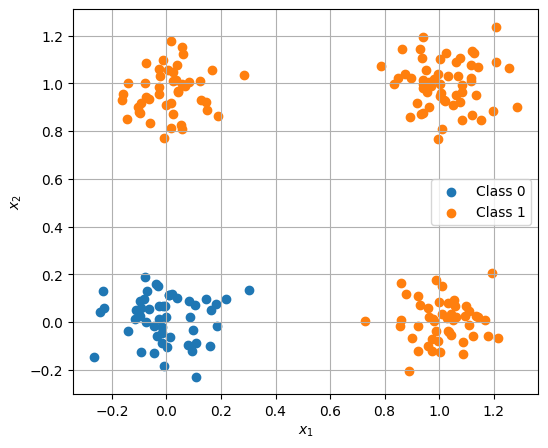

In [17]:
# Plot
mask = dataset.label.bool()
x = dataset.data[:,0]
y = dataset.data[:,1]
fig = plt.figure(figsize=(6,5))
axis = fig.add_subplot(1,1,1)
axis.scatter(x[~mask],y[~mask],label='Class 0')
axis.scatter(x[mask],y[mask],label='Class 1')
plt.ylabel("$x_2$")
plt.xlabel("$x_1$")
plt.legend()
plt.grid()

# Dataloader Class

In [18]:
#DataLoader??
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

In [19]:
# Display input and label.
data_inputs, data_labels = next(iter(dataloader))
print(f"Input batch shape: {data_inputs.size()}")
print(f"Labels batch shape: {data_labels.size()}")

Input batch shape: torch.Size([8, 2])
Labels batch shape: torch.Size([8])


In [20]:
# Loss Function:  Binary Cross Entropy (BCE) 
loss_module = nn.BCEWithLogitsLoss()

In [21]:
# Use Stochastic Gradient Descent
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

In [22]:
# Training
train_dataset = XORDataset(size=2500)
train_data_loader = DataLoader(train_dataset,batch_size=128,shuffle=True)

In [23]:
def train_model(model,optimizer, data_loader, loss_module, num_epochs=100):
    # Set model to train mode
    model.train() 
    
    # Training loop
    for epoch in tqdm(range(num_epochs)):
        for data_inputs, data_labels in data_loader:
            
            ## Step 1: Move input data to device (only strictly necessary if we use GPU)
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)
            
            ## Step 2: Run the model on the input data
            preds = model(data_inputs)
            preds = preds.squeeze(dim=1) # Output is [Batch size, 1], but we want [Batch size]
            
            ## Step 3: Calculate the loss
            loss = loss_module(preds, data_labels.float())
            
            ## Step 4: Perform backpropagation
            # Before calculating the gradients, we need to ensure that they are all zero. 
            # The gradients would not be overwritten, but actually added to the existing ones.
            optimizer.zero_grad() 
            # Perform backpropagation
            loss.backward()
            
            ## Step 5: Update the parameters
            optimizer.step()
            
        print('epoch : ', epoch, ', Loss : ', loss)

In [24]:
train_model(model, optimizer, train_data_loader, loss_module)

  0%|          | 0/100 [00:00<?, ?it/s]

epoch :  0 , Loss :  tensor(0.4745, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
epoch :  1 , Loss :  tensor(0.4628, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
epoch :  2 , Loss :  tensor(0.4162, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
epoch :  3 , Loss :  tensor(0.4441, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
epoch :  4 , Loss :  tensor(0.3911, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
epoch :  5 , Loss :  tensor(0.2910, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
epoch :  6 , Loss :  tensor(0.2611, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
epoch :  7 , Loss :  tensor(0.2142, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
epoch :  8 , Loss :  tensor(0.1452, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
epoch :  9 , Loss :  tensor(0.1344, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
epoch :  10 , Loss :  tensor(0.1052, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
epoch :  11 , Loss :  tensor(0.0867, grad_fn=<BinaryCrossEntropy

In [25]:
state_dict = model.state_dict()
print(state_dict)

OrderedDict({'linear1.weight': tensor([[ 2.2259,  2.1911],
        [ 1.7867,  1.9602],
        [ 0.4671,  0.6006],
        [-0.7249,  0.0860]]), 'linear1.bias': tensor([-1.0972, -0.9317,  0.1389,  0.2959]), 'linear2.weight': tensor([[ 3.9337,  3.1158,  0.8034, -0.5541]]), 'linear2.bias': tensor([0.1103])})


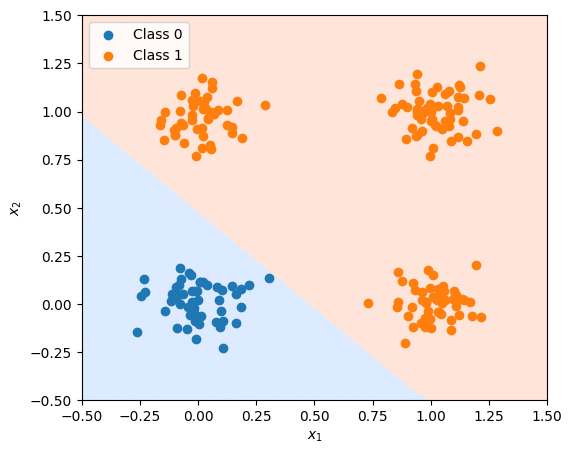

In [30]:
# ============================================================
# VISUALIZE DECISION BOUNDARY
# ============================================================
from matplotlib.colors import ListedColormap

x1 = np.linspace(-0.5, 1.5, 200)
x2 = np.linspace(-0.5, 1.5, 200)

xx1, xx2 = np.meshgrid(x1, x2)

# ------------------------------------------------------------
# Convert grid into list of coordinates
# ------------------------------------------------------------
background_cmap = ListedColormap([
    "#DCEBFF",   # light blue
    "#FFE5D9"    # light orange
])

grid_points = np.stack([xx1.ravel(), xx2.ravel()],axis=1)

grid_points_tensor = torch.tensor(grid_points,dtype=torch.float32)

model.eval()

with torch.no_grad():
    preds = model(grid_points_tensor)
    preds = torch.sigmoid(preds)
    preds = (preds >= 0.5).float()
    preds = preds.reshape(xx1.shape)

fig = plt.figure(figsize=(6,5))
axis = fig.add_subplot(1,1,1)

# Background image 
axis.imshow(preds.numpy(),origin='lower',extent=(-0.5,1.5,-0.5,1.5),aspect='auto',cmap=background_cmap)

# Draw Data points 
mask = dataset.label.bool()
x = dataset.data[:,0]
y = dataset.data[:,1]

axis.scatter(x[~mask],y[~mask],label='Class 0')
axis.scatter(x[mask],y[mask],label='Class 1')
plt.ylabel("$x_2$")
plt.xlabel("$x_1$")
plt.legend()
#plt.grid()

#plt.savefig('and_db.png')
#plt.savefig('xor_db.png')
plt.savefig('or_db.png')
#plt.savefig('nand_db.png')


In [35]:
# Model Evaluation
test_dataset = XORDataset(size=500)
test_data_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, drop_last=False)


In [56]:
def eval_model(model, test_data_loader):
    model.eval() # Set model to eval mode
    true_preds, num_preds = 0., 0.
    with torch.no_grad(): # Deactivate gradients for the following code
        preds_labels = 0
        for data_inputs, data_labels in test_data_loader:
            preds = model(data_inputs)
            preds = preds.squeeze(dim=1)
            preds = torch.sigmoid(preds)
            preds_labels = (preds > 0.5).long()
            #print("X")       
        # Keep records of predictions for the accuracy metric (true_preds=TP+TN, num_preds=TP+TN+FP+FN)
            true_preds += (preds_labels == data_labels).sum()
            num_preds += data_labels.shape[0]
            
    acc = true_preds / num_preds
    print(f"Accuracy of the model: {100.0*acc:4.2f}%")

In [54]:
eval_model(model, test_data_loader)

X
X
X
X
Accuracy of the model: 100.00%


512